# 🌐 Language Fairness in Tokenization
## Cell 1 — Install Dependencies
Install all required free libraries: tiktoken for GPT tokenization, and standard data science stack.

In [1]:
!pip install tiktoken pandas numpy matplotlib seaborn regex --quiet

## Cell 2 — Imports & Configuration
Import all libraries and set global constants: language list, color palette, and matplotlib style settings.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import regex as re
import tiktoken
import warnings
warnings.filterwarnings('ignore')

LANGUAGES = ['english', 'tamil', 'hindi', 'french']

LANG_COLORS = {
    'english': '#4C72B0',
    'tamil':   '#DD8452',
    'hindi':   '#55A868',
    'french':  '#C44E52'
}

plt.rcParams['figure.dpi']      = 130
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All imports successful')
print(f'   Languages : {LANGUAGES}')
print(f'   Colors    : {LANG_COLORS}')

✅ All imports successful
   Languages : ['english', 'tamil', 'hindi', 'french']
   Colors    : {'english': '#4C72B0', 'tamil': '#DD8452', 'hindi': '#55A868', 'french': '#C44E52'}


## Cell 3 — Load Dataset
Load `tokenfair_dataset_2000.csv`, drop rows with nulls in any language column, and preview the data.

In [3]:
import os
_csv_path = '/Users/asikaa/Documents/TokenFair/tokenfair_dataset_2000.csv'
print(f'Loading from: {_csv_path}')
df = pd.read_csv(_csv_path)

# Drop rows where any language column is null
df = df.dropna(subset=LANGUAGES).reset_index(drop=True)

# Ensure all language columns are strings
for lang in LANGUAGES:
    df[lang] = df[lang].astype(str).str.strip()

# Remove rows that became empty strings after stripping
mask = pd.Series([True] * len(df))
for lang in LANGUAGES:
    mask = mask & (df[lang].str.len() > 0)
df = df[mask].reset_index(drop=True)

print(f'📊 Dataset loaded successfully')
print(f'   Total rows  : {len(df)}')
if 'domain' in df.columns:
    domains = df['domain'].unique().tolist()
    print(f'   Domains     : {len(domains)}')
    print(f'   Domain list : {domains}')
else:
    print('   No domain column found — proceeding without domain grouping')

print(f'   Columns     : {list(df.columns)}')
df.head(3)

Loading from: /Users/asikaa/Documents/TokenFair/tokenfair_dataset_2000.csv
📊 Dataset loaded successfully
   Total rows  : 1878
   Domains     : 20
   Domain list : ['Healthcare', 'Legal', 'Education', 'Technology', 'E-commerce', 'Banking', 'Agriculture', 'Politics', 'Sports', 'Entertainment', 'Travel', 'Food', 'Weather', 'Family', 'Employment', 'Environment', 'Science', 'Social media', 'Government', 'Religion']
   Columns     : ['domain', 'english', 'tamil', 'hindi', 'french']


,domain,english,tamil,hindi,french
0,Healthcare,The patient needs to take medicine twice a day.,நோயாளி ஒரு நாளைக்கு இரண்டு முறை மருந்து எடுக்க...,मरीज को दिन में दो बार दवा खानी पड़ती है।,Le patient doit prendre des médicaments deux f...
1,Healthcare,It is important that the patient needs to take...,நோயாளி ஒரு நாளைக்கு இரண்டு முறை மருந்து சாப்பி...,जरूरी है कि मरीज को दिन में दो बार दवा खानी पड़े.,Il est important que le patient prenne ses méd...
2,Healthcare,Remember that the patient needs to take medici...,நோயாளி ஒரு நாளைக்கு இரண்டு முறை மருந்து எடுக்க...,याद रखें कि मरीज को दिन में दो बार दवा लेनी है।,N'oubliez pas que le patient doit prendre ses ...


## Cell 4 — Custom Fair Tokenizer
A Unicode-aware tokenizer class: akshara-level syllables for Tamil and Hindi, word+punctuation tokens for English and French.

In [4]:
class CustomFairTokenizer:
    """
    Language-aware tokenizer:
    - Tamil  : Unicode syllable (akshara) tokenization  \u0B80-\u0BFF
    - Hindi  : Devanagari syllable tokenization          \u0900-\u097F
    - English/French : word + punctuation split
    """

    # Tamil: consonant/vowel/independent vowel + optional vowel marks/virama
    TAMIL_SYLLABLE = re.compile(
        r'[\u0B85-\u0B8A\u0B8E-\u0B90\u0B92-\u0B95\u0B99\u0B9A\u0B9C\u0B9E\u0B9F'
        r'\u0BA3\u0BA4\u0BA8-\u0BAA\u0BAE-\u0BB9]'
        r'[\u0BBE-\u0BC2\u0BC6-\u0BC8\u0BCA-\u0BCD\u0BD7]?'
        r'|[\u0B85-\u0B8A\u0B8E-\u0B90\u0B92-\u0B95]'
    )

    # Hindi (Devanagari): consonant + optional vowel mark / halant
    HINDI_SYLLABLE = re.compile(
        r'[\u0915-\u0939\u0958-\u095F\u0960\u0961]'
        r'[\u093E-\u094C\u094D]?'
        r'|[\u0905-\u0914\u0960\u0961]'
    )

    # Latin (English / French): word tokens and punctuation
    LATIN_TOKEN = re.compile(r"\w+(?:'\w+)*|[^\w\s]")

    def tokenize(self, text: str, lang: str) -> list:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return []
        if lang == 'tamil':
            tokens = self.TAMIL_SYLLABLE.findall(text)
            # Fallback: if no syllables found, split on whitespace
            if not tokens:
                tokens = text.split()
            return tokens
        elif lang == 'hindi':
            tokens = self.HINDI_SYLLABLE.findall(text)
            if not tokens:
                tokens = text.split()
            return tokens
        else:  # english, french
            return self.LATIN_TOKEN.findall(text)

    def count(self, text: str, lang: str) -> int:
        return len(self.tokenize(text, lang))


# ── Quick test ────────────────────────────────────────────
custom_tok = CustomFairTokenizer()

test_sentences = {
    'english': 'The patient requires immediate medical attention.',
    'tamil':   'நோயாளிக்கு உடனடி மருத்துவ கவனிப்பு தேவை.',
    'hindi':   'रोगी को तत्काल चिकित्सा ध्यान की आवश्यकता है।',
    'french':  'Le patient nécessite une attention médicale immédiate.',
}

print('🔬 Custom Tokenizer Test Results')
print('=' * 55)
for lang, sent in test_sentences.items():
    tokens = custom_tok.tokenize(sent, lang)
    print(f'  {lang.upper():<8} | {len(tokens):>3} tokens | {tokens[:6]}...')

🔬 Custom Tokenizer Test Results
  ENGLISH  |   7 tokens | ['The', 'patient', 'requires', 'immediate', 'medical', 'attention']...
  TAMIL    |  21 tokens | ['நோ', 'யா', 'ளி', 'க்', 'கு', 'உ']...
  HINDI    |  22 tokens | ['रो', 'गी', 'को', 'त', 'त्', 'का']...
  FRENCH   |   8 tokens | ['Le', 'patient', 'nécessite', 'une', 'attention', 'médicale']...


## Cell 5 — GPT Tokenizer (tiktoken)
Load GPT-4 / GPT-3.5 tokenizer `cl100k_base` via tiktoken — 100% local, no API calls required.

In [5]:
# Load cl100k_base (GPT-3.5 / GPT-4) — fully local
enc = tiktoken.get_encoding('cl100k_base')

def gpt_token_count(text: str) -> int:
    """Return number of GPT tokens for a text string."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0
    return len(enc.encode(text))

# ── Quick test on same 4 sentences ────────────────────────
print('🤖 GPT (cl100k_base) Tokenizer Test Results')
print('=' * 55)
for lang, sent in test_sentences.items():
    count = gpt_token_count(sent)
    tokens = enc.encode(sent)
    decoded_preview = [enc.decode([t]) for t in tokens[:6]]
    print(f'  {lang.upper():<8} | {count:>3} tokens | preview: {decoded_preview}')

print(f'\n✅ Encoding: cl100k_base (GPT-4 / GPT-3.5-Turbo)')
print(f'   Vocab size: {enc.n_vocab:,}')

🤖 GPT (cl100k_base) Tokenizer Test Results
  ENGLISH  |   7 tokens | preview: ['The', ' patient', ' requires', ' immediate', ' medical', ' attention']
  TAMIL    |  56 tokens | preview: ['�', '�', '�', '�', '�', '�']
  HINDI    |  47 tokens | preview: ['र', 'ो', '�', '�', 'ी', ' क']
  FRENCH   |  13 tokens | preview: ['Le', ' patient', ' nécess', 'ite', ' une', ' attention']

✅ Encoding: cl100k_base (GPT-4 / GPT-3.5-Turbo)
   Vocab size: 100,277


## Cell 6 — Compute All Token Counts
Apply GPT tokenizer, custom tokenizer, and naive word count to every sentence × language combination.

In [6]:
print('⏳ Computing token counts for all sentences × languages...')
print('   (This may take 30–60 seconds for ~1879 rows)')

for i, lang in enumerate(LANGUAGES):
    print(f'   Processing {lang}...', end=' ')

    # GPT token count
    df[f'gpt_{lang}'] = df[lang].apply(gpt_token_count)

    # Custom tokenizer count
    df[f'custom_{lang}'] = df[lang].apply(
        lambda x: custom_tok.count(x, lang)
    )

    # Naive word count
    df[f'words_{lang}'] = df[lang].apply(
        lambda x: len(str(x).split()) if isinstance(x, str) else 0
    )

    print(f'✅  (GPT avg: {df[f"gpt_{lang}"].mean():.1f})')

print('\n📊 Mean GPT Token Counts per Language')
print('=' * 40)
eng_mean = df['gpt_english'].mean()
for lang in LANGUAGES:
    mean_val = df[f'gpt_{lang}'].mean()
    overhead = ((mean_val - eng_mean) / eng_mean * 100) if lang != 'english' else 0.0
    sign = '+' if overhead >= 0 else ''
    print(f'  {lang.upper():<10} : {mean_val:6.2f} tokens  ({sign}{overhead:.1f}% vs English)')

print(f'\n✅ All token count columns added. DataFrame shape: {df.shape}')

⏳ Computing token counts for all sentences × languages...
   (This may take 30–60 seconds for ~1879 rows)
   Processing english... ✅  (GPT avg: 12.3)
   Processing tamil... ✅  (GPT avg: 105.6)
   Processing hindi... ✅  (GPT avg: 68.4)
   Processing french... ✅  (GPT avg: 20.5)

📊 Mean GPT Token Counts per Language
  ENGLISH    :  12.28 tokens  (+0.0% vs English)
  TAMIL      : 105.60 tokens  (+759.8% vs English)
  HINDI      :  68.37 tokens  (+456.7% vs English)
  FRENCH     :  20.53 tokens  (+67.1% vs English)

✅ All token count columns added. DataFrame shape: (1878, 17)


## Cell 7 — Tokenization Inequality Score (TIS) [Novel Metric]
TIS measures how many more tokens a language needs compared to English — a direct measure of tokenization bias.

In [7]:
NON_ENGLISH = ['tamil', 'hindi', 'french']

# Compute TIS for GPT tokenizer
for lang in NON_ENGLISH:
    df[f'tis_gpt_{lang}'] = (
        df[f'gpt_{lang}'].replace(0, np.nan) /
        df['gpt_english'].replace(0, np.nan)
    ) - 1

# Compute TIS for Custom tokenizer
for lang in NON_ENGLISH:
    df[f'tis_custom_{lang}'] = (
        df[f'custom_{lang}'].replace(0, np.nan) /
        df['custom_english'].replace(0, np.nan)
    ) - 1

def tis_emoji(mean_tis: float) -> str:
    pct = mean_tis * 100
    if pct >= 40:
        return '🔴 HIGH BIAS'
    elif pct > 10:
        return '🟡 MODERATE'
    else:
        return '🟢 LOW'

print('📐 Tokenization Inequality Score (TIS) — GPT Tokenizer')
print('   TIS = (lang_tokens / english_tokens) - 1')
print('   Positive = more tokens than English (bias against that language)')
print('=' * 60)
for lang in NON_ENGLISH:
    mean_tis = df[f'tis_gpt_{lang}'].dropna().mean()
    pct = mean_tis * 100
    flag = tis_emoji(mean_tis)
    print(f'  {lang.upper():<8} : TIS = {mean_tis:+.4f}  ({pct:+.1f}%)  {flag}')

print()
print('📐 Tokenization Inequality Score (TIS) — Custom Tokenizer')
print('=' * 60)
for lang in NON_ENGLISH:
    mean_tis = df[f'tis_custom_{lang}'].dropna().mean()
    pct = mean_tis * 100
    flag = tis_emoji(mean_tis)
    print(f'  {lang.upper():<8} : TIS = {mean_tis:+.4f}  ({pct:+.1f}%)  {flag}')

print('\n✅ TIS columns computed for both tokenizers.')

📐 Tokenization Inequality Score (TIS) — GPT Tokenizer
   TIS = (lang_tokens / english_tokens) - 1
   Positive = more tokens than English (bias against that language)
  TAMIL    : TIS = +7.6918  (+769.2%)  🔴 HIGH BIAS
  HINDI    : TIS = +4.6242  (+462.4%)  🔴 HIGH BIAS
  FRENCH   : TIS = +0.6891  (+68.9%)  🔴 HIGH BIAS

📐 Tokenization Inequality Score (TIS) — Custom Tokenizer
  TAMIL    : TIS = +2.4374  (+243.7%)  🔴 HIGH BIAS
  HINDI    : TIS = +1.8050  (+180.5%)  🔴 HIGH BIAS
  FRENCH   : TIS = +0.1903  (+19.0%)  🟡 MODERATE

✅ TIS columns computed for both tokenizers.


## Cell 8 — Plot 1: Average Token Counts Bar Chart
Side-by-side comparison of mean token counts per language for GPT vs Custom tokenizer.

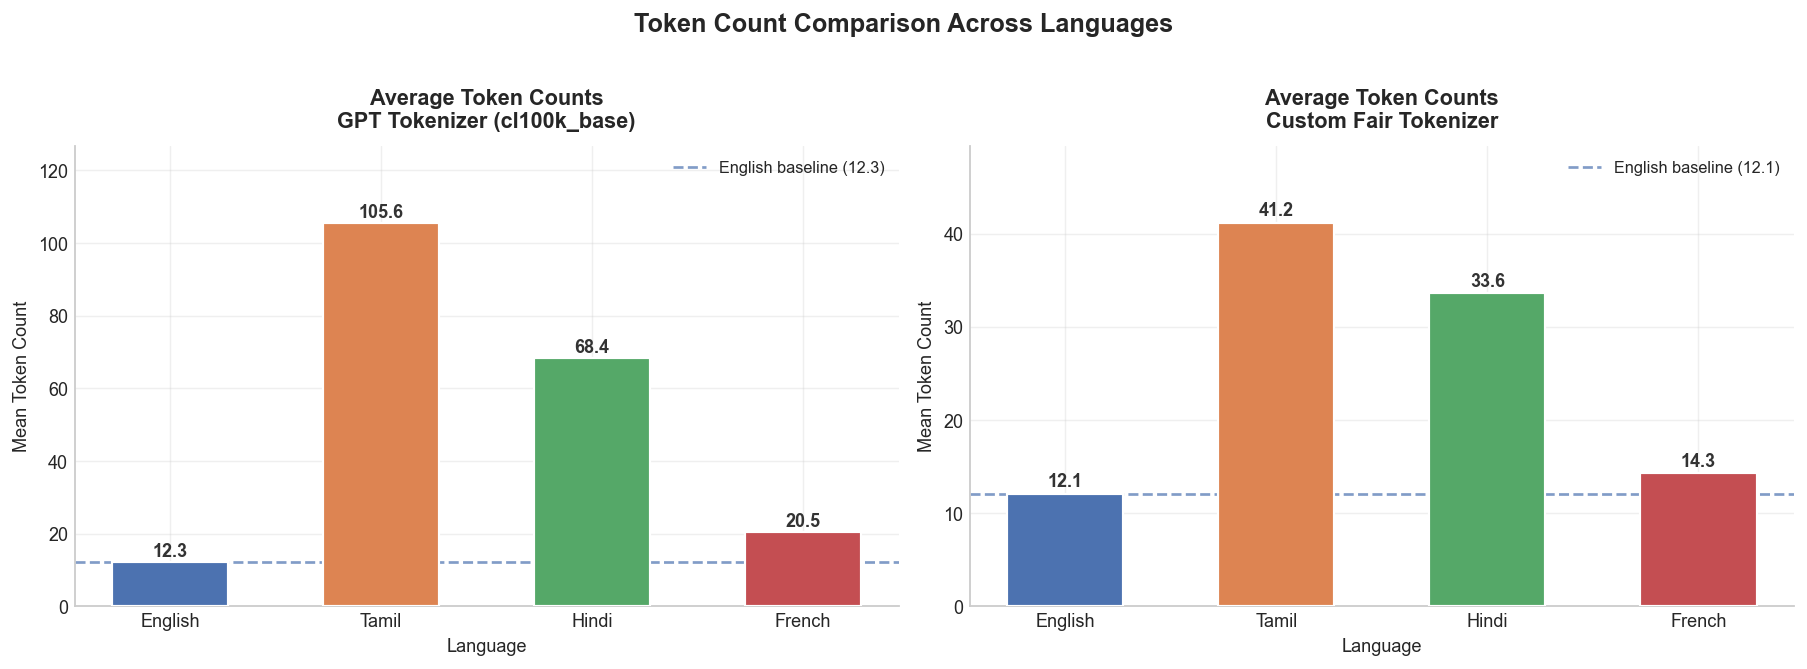

✅ Saved: plot1_avg_token_counts.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tok_prefix, title in zip(
    axes,
    ['gpt', 'custom'],
    ['GPT Tokenizer (cl100k_base)', 'Custom Fair Tokenizer']
):
    means = [df[f'{tok_prefix}_{lang}'].mean() for lang in LANGUAGES]
    colors = [LANG_COLORS[lang] for lang in LANGUAGES]
    bars = ax.bar(LANGUAGES, means, color=colors, edgecolor='white',
                  linewidth=1.2, width=0.55, zorder=3)

    # English baseline
    eng_mean = df[f'{tok_prefix}_english'].mean()
    ax.axhline(eng_mean, color=LANG_COLORS['english'], linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'English baseline ({eng_mean:.1f})')

    # Value labels on bars
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='#333333')

    ax.set_title(f'Average Token Counts\n{title}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Language', fontsize=10)
    ax.set_ylabel('Mean Token Count', fontsize=10)
    ax.set_xticklabels([l.capitalize() for l in LANGUAGES], fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(means) * 1.2)

fig.suptitle('Token Count Comparison Across Languages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot1_avg_token_counts.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot1_avg_token_counts.png')

## Cell 9 — Plot 2: TIS Distribution Boxplot
Distribution of per-sentence TIS values for Tamil, Hindi, and French — showing spread of tokenization inequality.

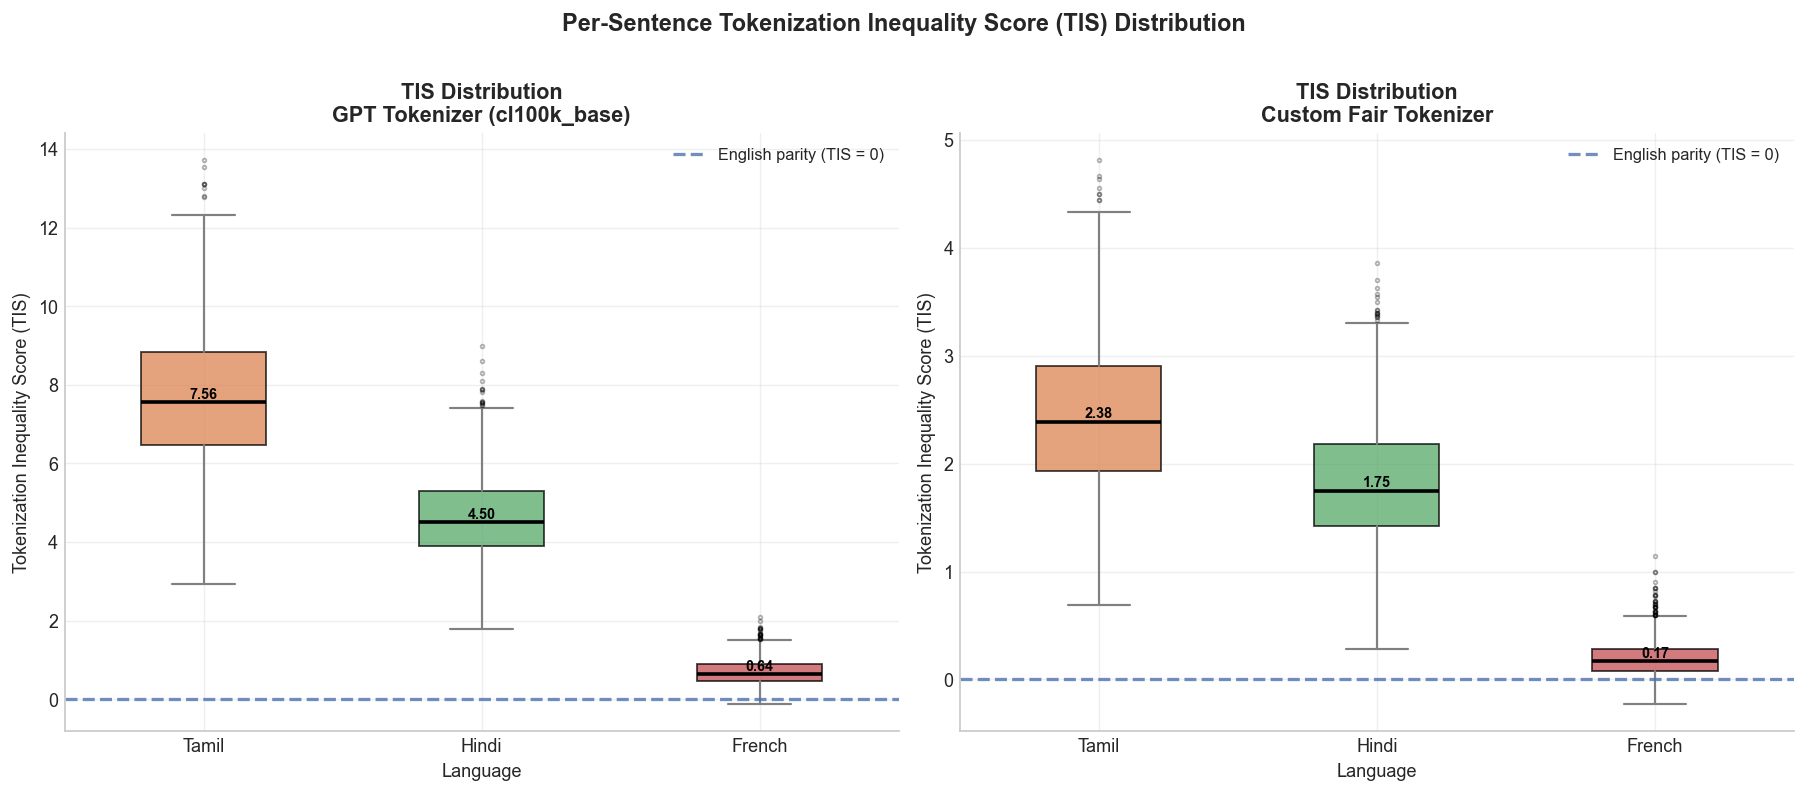

✅ Saved: plot2_tis_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tok_prefix, title in zip(
    axes,
    ['gpt', 'custom'],
    ['GPT Tokenizer (cl100k_base)', 'Custom Fair Tokenizer']
):
    tis_data   = [df[f'tis_{tok_prefix}_{lang}'].dropna().values for lang in NON_ENGLISH]
    box_colors = [LANG_COLORS[lang] for lang in NON_ENGLISH]

    bp = ax.boxplot(
        tis_data,
        labels=[l.capitalize() for l in NON_ENGLISH],
        patch_artist=True,
        notch=False,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        widths=0.45
    )

    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    for whisker in bp['whiskers']:
        whisker.set(color='gray', linewidth=1.2)
    for cap in bp['caps']:
        cap.set(color='gray', linewidth=1.2)

    # English parity line at y=0
    ax.axhline(0, color='#4C72B0', linestyle='--', linewidth=1.8,
               alpha=0.8, label='English parity (TIS = 0)')

    ax.set_title(f'TIS Distribution\n{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Language', fontsize=10)
    ax.set_ylabel('Tokenization Inequality Score (TIS)', fontsize=10)
    ax.legend(fontsize=9)

    # Annotate median values
    for i, lang in enumerate(NON_ENGLISH, 1):
        median_val = df[f'tis_{tok_prefix}_{lang}'].dropna().median()
        ax.text(i, median_val + 0.01, f'{median_val:.2f}',
                ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')

fig.suptitle('Per-Sentence Tokenization Inequality Score (TIS) Distribution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot2_tis_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot2_tis_distribution.png')

## Cell 10 — Plot 3: TIS Heatmap by Domain
Domain-level heatmap showing where tokenization bias is highest — revealing structural patterns across content types.

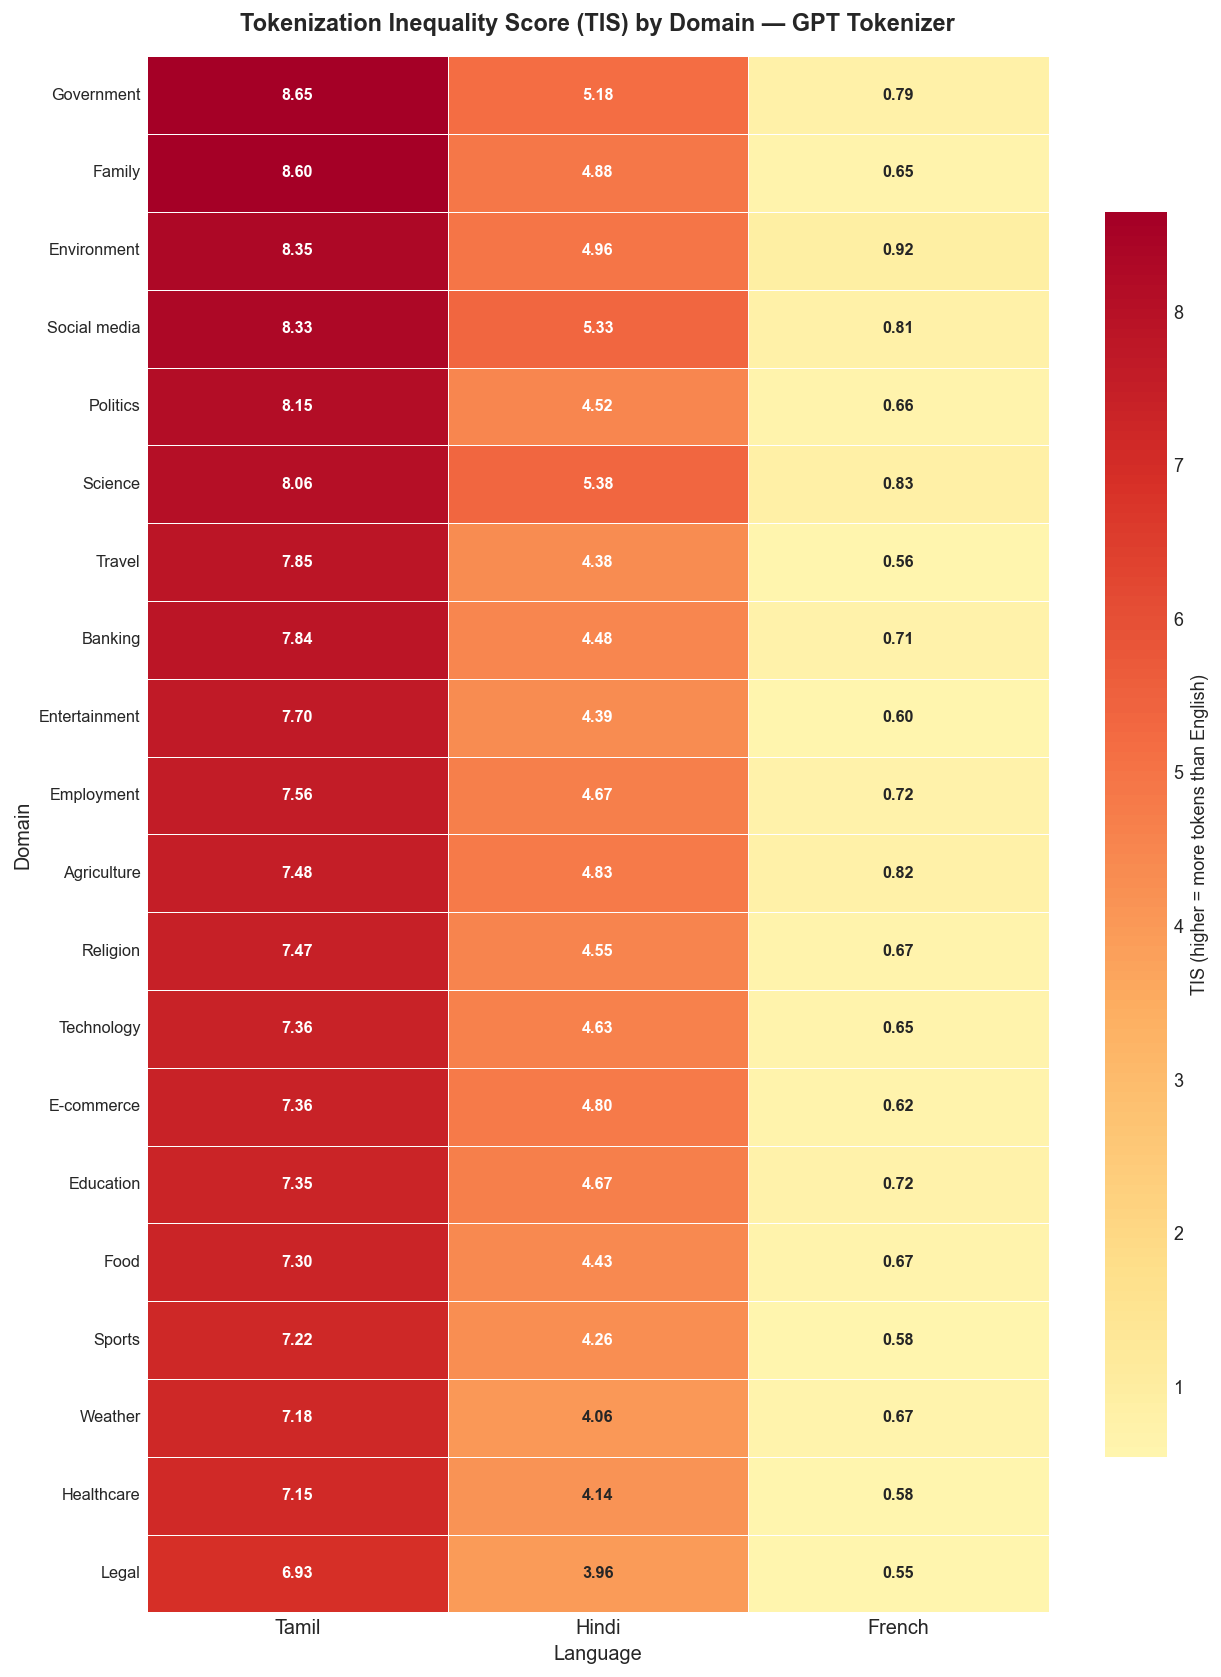

✅ Saved: plot3_tis_heatmap.png
   Domains in heatmap: ['Government', 'Family', 'Environment', 'Social media', 'Politics', 'Science', 'Travel', 'Banking', 'Entertainment', 'Employment', 'Agriculture', 'Religion', 'Technology', 'E-commerce', 'Education', 'Food', 'Sports', 'Weather', 'Healthcare', 'Legal']


In [10]:
if 'domain' not in df.columns:
    df['domain'] = 'general'

tis_cols = {lang: f'tis_gpt_{lang}' for lang in NON_ENGLISH}

# Group by domain and compute mean TIS
domain_tis = df.groupby('domain')[list(tis_cols.values())].mean()
domain_tis.columns = [l.capitalize() for l in NON_ENGLISH]
domain_tis = domain_tis.sort_values('Tamil', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(domain_tis) * 0.55 + 2)))

sns.heatmap(
    domain_tis,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'TIS (higher = more tokens than English)', 'shrink': 0.8},
    annot_kws={'size': 9, 'weight': 'bold'}
)

ax.set_title('Tokenization Inequality Score (TIS) by Domain — GPT Tokenizer',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('Domain', fontsize=11)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot3_tis_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot3_tis_heatmap.png')
print(f'   Domains in heatmap: {list(domain_tis.index)}')

## Cell 11 — API Cost Calculator [Novel Feature]
Simulate real-world GPT-3.5-Turbo API costs at scale (1000 users × all sentences). Quantifies economic impact of tokenization bias.

In [11]:
INPUT_PRICE_PER_1K  = 0.0005   # USD per 1K input tokens  (GPT-3.5-Turbo)
OUTPUT_PRICE_PER_1K = 0.0015   # USD per 1K output tokens (GPT-3.5-Turbo)
COMBINED_PRICE      = INPUT_PRICE_PER_1K + OUTPUT_PRICE_PER_1K  # 0.002
SCALE_FACTOR        = 1000     # number of users

cost_data = {}

print('💰 API Cost Simulation — GPT-3.5-Turbo Pricing')
print(f'   Input  : ${INPUT_PRICE_PER_1K}/1K tokens')
print(f'   Output : ${OUTPUT_PRICE_PER_1K}/1K tokens')
print(f'   Scale  : {SCALE_FACTOR:,} users')
print('=' * 60)

for lang in LANGUAGES:
    total_tokens  = df[f'gpt_{lang}'].sum()
    scaled_tokens = total_tokens * SCALE_FACTOR
    total_cost    = (scaled_tokens / 1000) * COMBINED_PRICE
    cost_data[lang] = {
        'total_tokens':  total_tokens,
        'scaled_tokens': scaled_tokens,
        'total_cost_usd': total_cost
    }
    print(f'  {lang.upper():<10}: {total_tokens:>8,} tokens  →  '
          f'{scaled_tokens:>12,} scaled  →  ${total_cost:>8.4f}')

print()
print('📈 Extra Cost vs English (Overhead)')
print('=' * 60)
eng_cost = cost_data['english']['total_cost_usd']
eng_tok  = cost_data['english']['total_tokens']

for lang in NON_ENGLISH:
    lang_cost = cost_data[lang]['total_cost_usd']
    lang_tok  = cost_data[lang]['total_tokens']
    extra_usd = lang_cost - eng_cost
    extra_pct = ((lang_cost - eng_cost) / eng_cost) * 100
    extra_tok = lang_tok - eng_tok
    sign = '+' if extra_usd >= 0 else ''
    print(f'  {lang.upper():<10}: {sign}${extra_usd:.4f}  ({sign}{extra_pct:.1f}%)  '
          f'| {sign}{extra_tok:,} extra tokens')

cost_df = pd.DataFrame(cost_data).T.reset_index()
cost_df.columns = ['language', 'total_tokens', 'scaled_tokens', 'total_cost_usd']
print(f'\n✅ cost_df created with {len(cost_df)} rows')

💰 API Cost Simulation — GPT-3.5-Turbo Pricing
   Input  : $0.0005/1K tokens
   Output : $0.0015/1K tokens
   Scale  : 1,000 users
  ENGLISH   :   23,066 tokens  →    23,066,000 scaled  →  $ 46.1320
  TAMIL     :  198,324 tokens  →   198,324,000 scaled  →  $396.6480
  HINDI     :  128,406 tokens  →   128,406,000 scaled  →  $256.8120
  FRENCH    :   38,549 tokens  →    38,549,000 scaled  →  $ 77.0980

📈 Extra Cost vs English (Overhead)
  TAMIL     : +$350.5160  (+759.8%)  | +175,258 extra tokens
  HINDI     : +$210.6800  (+456.7%)  | +105,340 extra tokens
  FRENCH    : +$30.9660  (+67.1%)  | +15,483 extra tokens

✅ cost_df created with 4 rows


## Cell 12 — Plot 4: API Cost Bar Chart
Visualize the economic cost of tokenization bias — how much more expensive it is to run non-English queries at scale.

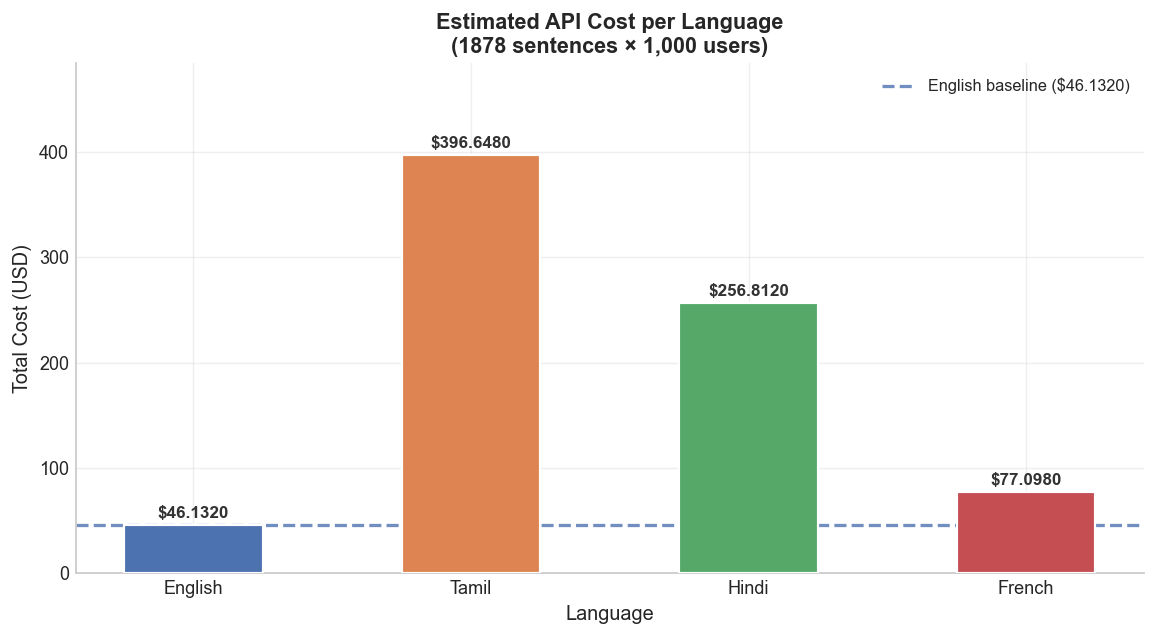

✅ Saved: plot4_api_cost.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

langs   = [row['language'] for _, row in cost_df.iterrows()]
costs   = [row['total_cost_usd'] for _, row in cost_df.iterrows()]
colors  = [LANG_COLORS[lang] for lang in langs]

bars = ax.bar(langs, costs, color=colors, edgecolor='white',
              linewidth=1.2, width=0.5, zorder=3)

# English baseline
eng_cost_val = cost_data['english']['total_cost_usd']
ax.axhline(eng_cost_val, color=LANG_COLORS['english'],
           linestyle='--', linewidth=1.8, alpha=0.8,
           label=f'English baseline (${eng_cost_val:.4f})')

# Value labels
for bar, cost in zip(bars, costs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(costs) * 0.01,
            f'${cost:.4f}',
            ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color='#333333')

ax.set_title(
    f'Estimated API Cost per Language\n({len(df)} sentences × {SCALE_FACTOR:,} users)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('Total Cost (USD)', fontsize=11)
ax.set_xticklabels([l.capitalize() for l in langs], fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, max(costs) * 1.22)

plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot4_api_cost.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot4_api_cost.png')

## Cell 13 — Semantic Density Analysis [Novel Feature]
Semantic Density = words / GPT tokens. Measures how efficiently a tokenizer packs meaning — higher = more information per token.

In [13]:
print('🧠 Semantic Density Analysis')
print('   Definition: mean(words / gpt_tokens) per sentence')
print('   Higher = more semantically dense per token')
print('=' * 55)

density_results = {}

for lang in LANGUAGES:
    # Per-sentence density: words / gpt_tokens (avoid division by zero)
    gpt_col   = df[f'gpt_{lang}'].replace(0, np.nan)
    words_col = df[f'words_{lang}']
    density   = (words_col / gpt_col).dropna().mean()
    density_results[lang] = density

    bar_len = int(density * 20)
    bar_str = '█' * bar_len
    print(f'  {lang.upper():<10}: {density:.4f}  {bar_str}')

max_lang  = max(density_results, key=density_results.get)
min_lang  = min(density_results, key=density_results.get)

print()
print(f'  🏆 Most efficient  : {max_lang.upper()} '
      f'({density_results[max_lang]:.4f} words/token)')
print(f'  🐌 Least efficient : {min_lang.upper()} '
      f'({density_results[min_lang]:.4f} words/token)')

ratio = density_results[max_lang] / density_results[min_lang]
print(f'\n  Efficiency gap: {max_lang} packs {ratio:.2f}x more meaning '
      f'per GPT token than {min_lang}')

print('\n✅ Semantic density computed for all languages.')

🧠 Semantic Density Analysis
   Definition: mean(words / gpt_tokens) per sentence
   Higher = more semantically dense per token
  ENGLISH   : 0.8857  █████████████████
  TAMIL     : 0.0782  █
  HINDI     : 0.1963  ███
  FRENCH    : 0.6193  ████████████

  🏆 Most efficient  : ENGLISH (0.8857 words/token)
  🐌 Least efficient : TAMIL (0.0782 words/token)

  Efficiency gap: english packs 11.33x more meaning per GPT token than tamil

✅ Semantic density computed for all languages.


## Cell 14 — Context Window Shrinkage Simulation [Novel Feature]
Simulates how many sentences fit into different LLM context windows per language — quantifying real capacity loss.

In [14]:
CONTEXT_WINDOWS = {
    'GPT-3.5 (4K)':   4096,
    'GPT-4 (8K)':     8192,
    'GPT-4 (128K)':   128000,
    'Claude 3 (200K)':200000,
}

# Average GPT tokens per sentence per language
avg_gpt = {lang: df[f'gpt_{lang}'].replace(0, np.nan).mean() for lang in LANGUAGES}

shrinkage_rows = []
for model_name, ctx_size in CONTEXT_WINDOWS.items():
    row = {'model': model_name, 'context_tokens': ctx_size}
    for lang in LANGUAGES:
        sentences_fit = int(ctx_size / avg_gpt[lang]) if avg_gpt[lang] else 0
        row[lang] = sentences_fit
    shrinkage_df = shrinkage_rows  # will assign below
    shrinkage_rows.append(row)

shrinkage_df = pd.DataFrame(shrinkage_rows)

print('📦 Context Window Shrinkage Simulation')
print('   Values = number of sentences that fit in the context window')
print('=' * 70)
print(f'  {"Model":<22} {"Ctx":>8}  '
      f'{"English":>10} {"Tamil":>10} {"Hindi":>10} {"French":>10}')
print(f'  {"-"*68}')

for _, row in shrinkage_df.iterrows():
    eng_fit = row['english']
    print(
        f'  {row["model"]:<22} {row["context_tokens"]:>8,}  '
        f'{row["english"]:>10,} '
        f'{row["tamil"]:>10,} ({100*row["tamil"]//max(eng_fit,1):2d}%)'
        f'{row["hindi"]:>10,} ({100*row["hindi"]//max(eng_fit,1):2d}%)'
        f'{row["french"]:>10,} ({100*row["french"]//max(eng_fit,1):2d}%)'
    )

print(f'\n✅ shrinkage_df created: {shrinkage_df.shape}')
shrinkage_df

📦 Context Window Shrinkage Simulation
   Values = number of sentences that fit in the context window
  Model                       Ctx     English      Tamil      Hindi     French
  --------------------------------------------------------------------
  GPT-3.5 (4K)              4,096         333         38 (11%)        59 (17%)       199 (59%)
  GPT-4 (8K)                8,192         666         77 (11%)       119 (17%)       399 (59%)
  GPT-4 (128K)            128,000      10,421      1,212 (11%)     1,872 (17%)     6,235 (59%)
  Claude 3 (200K)         200,000      16,283      1,893 (11%)     2,925 (17%)     9,743 (59%)

✅ shrinkage_df created: (4, 6)


,model,context_tokens,english,tamil,hindi,french
0,GPT-3.5 (4K),4096,333,38,59,199
1,GPT-4 (8K),8192,666,77,119,399
2,GPT-4 (128K),128000,10421,1212,1872,6235
3,Claude 3 (200K),200000,16283,1893,2925,9743


## Cell 15 — Plot 5: Context Window Shrinkage
Four subplots (one per model) showing sentences-that-fit per language — visualizing real-world capacity loss.

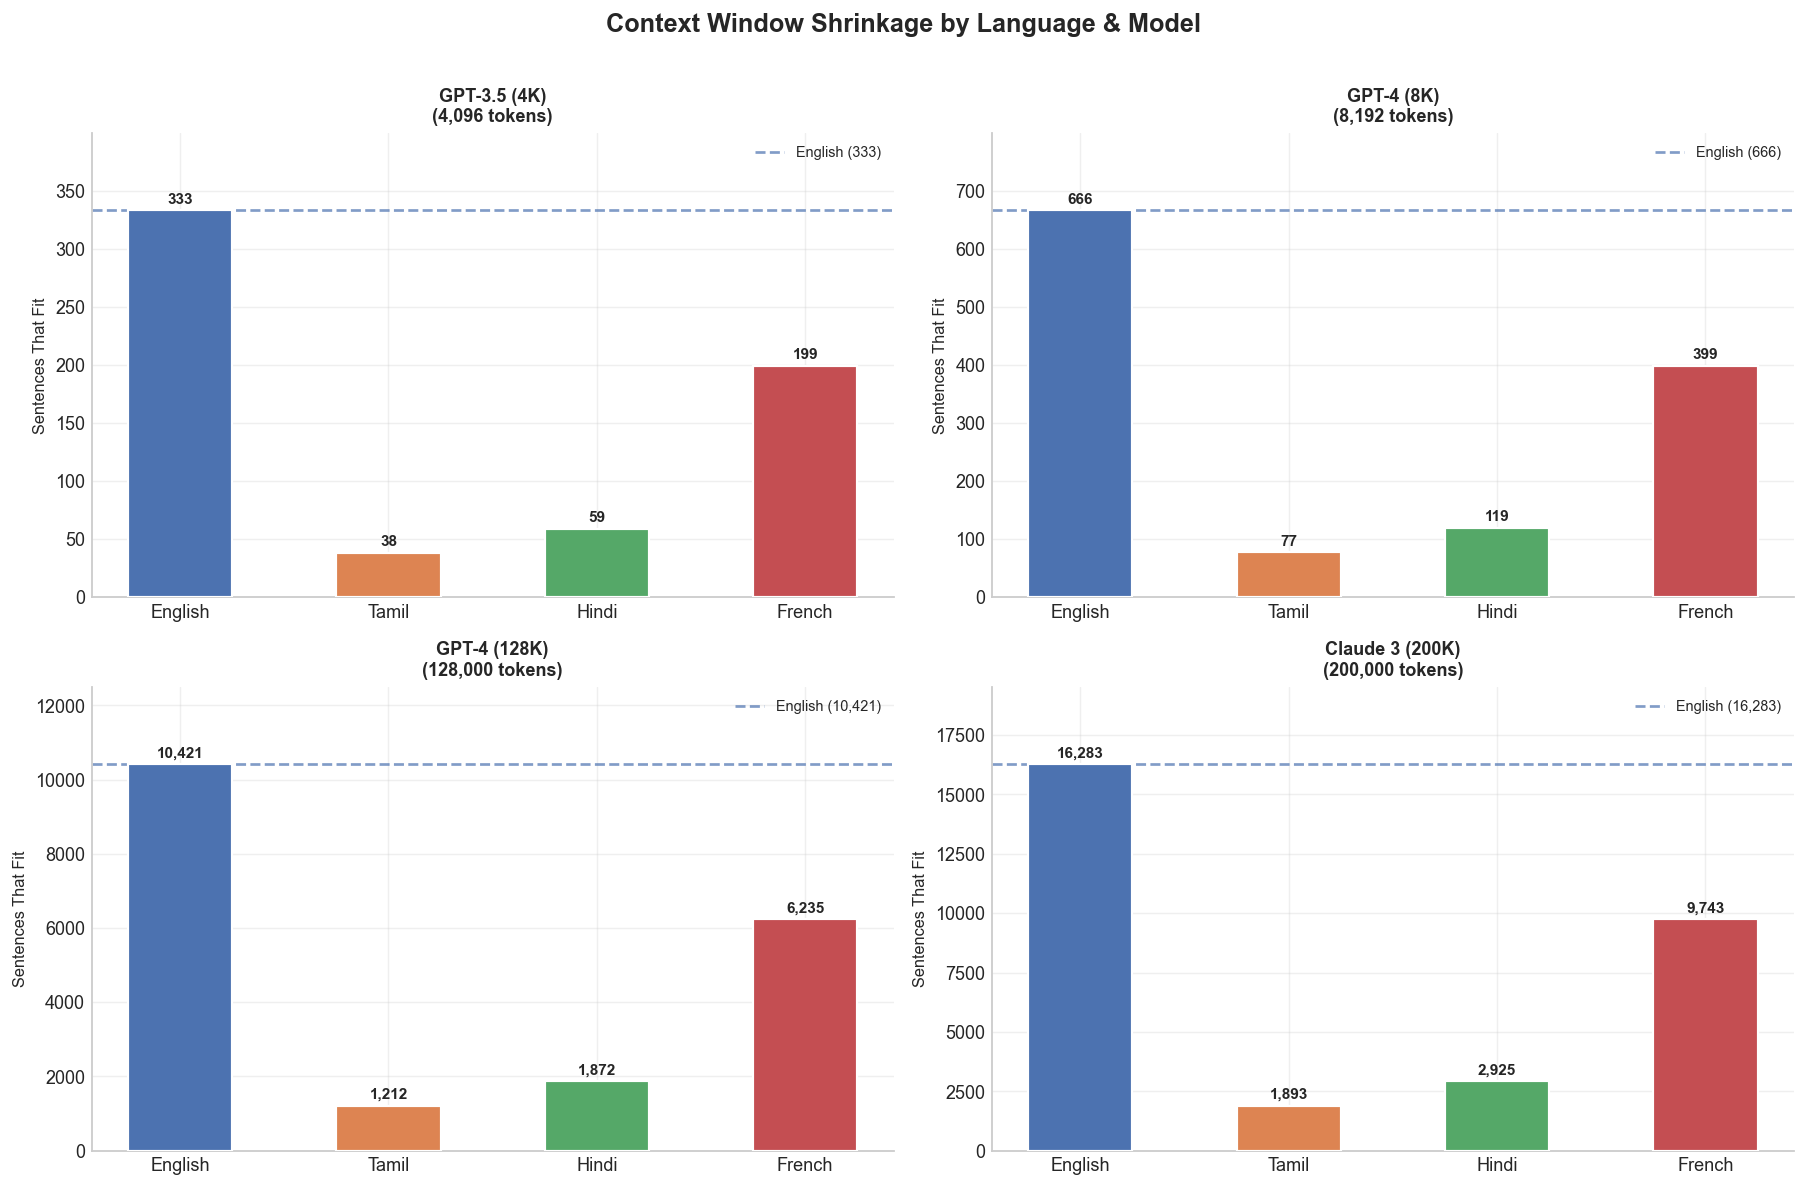

✅ Saved: plot5_context_shrinkage.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes_flat = axes.flatten()

for ax, (_, row) in zip(axes_flat, shrinkage_df.iterrows()):
    values  = [row[lang] for lang in LANGUAGES]
    colors  = [LANG_COLORS[lang] for lang in LANGUAGES]
    bars    = ax.bar(
        [l.capitalize() for l in LANGUAGES],
        values, color=colors,
        edgecolor='white', linewidth=1.2,
        width=0.5, zorder=3
    )

    # English baseline
    eng_val = row['english']
    ax.axhline(eng_val, color=LANG_COLORS['english'],
               linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'English ({eng_val:,})')

    # Value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f'{val:,}',
                ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')

    ax.set_title(f'{row["model"]}\n({row["context_tokens"]:,} tokens)',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Sentences That Fit', fontsize=9)
    ax.set_ylim(0, max(values) * 1.2)
    ax.legend(fontsize=8)

fig.suptitle('Context Window Shrinkage by Language & Model',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot5_context_shrinkage.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot5_context_shrinkage.png')

## Cell 16 — Plot 6: Script-Type Bias Scatter [Novel Feature]
Scatter plot of avg words vs avg GPT tokens per language, annotated by script family. Points above the diagonal have tokenization overhead.

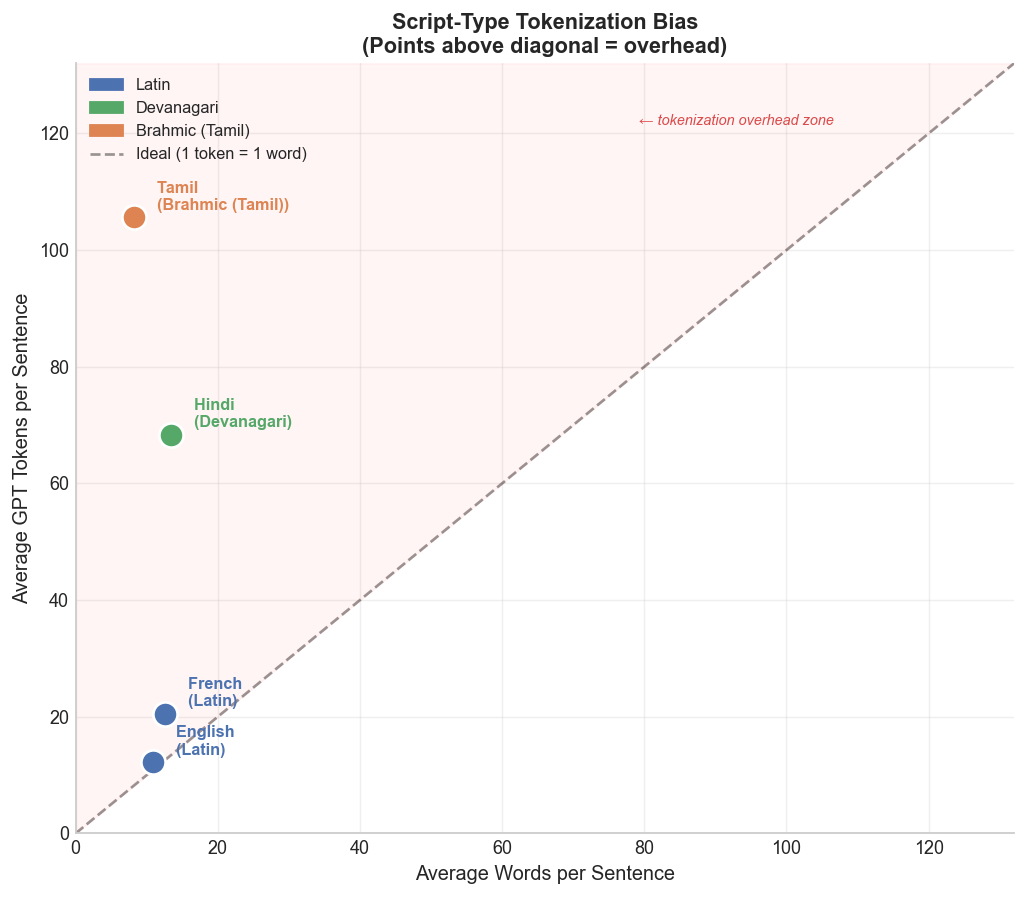

✅ Saved: plot6_script_bias.png


In [16]:
script_map = {
    'english': 'Latin',
    'french':  'Latin',
    'hindi':   'Devanagari',
    'tamil':   'Brahmic (Tamil)',
}

script_colors = {
    'Latin':           '#4C72B0',
    'Devanagari':      '#55A868',
    'Brahmic (Tamil)': '#DD8452',
}

avg_words = {lang: df[f'words_{lang}'].mean() for lang in LANGUAGES}
avg_gpt2  = {lang: df[f'gpt_{lang}'].mean()   for lang in LANGUAGES}

fig, ax = plt.subplots(figsize=(8, 7))

# y = x diagonal (ideal fair line: 1 token = 1 word)
all_vals = list(avg_words.values()) + list(avg_gpt2.values())
diag_max = max(all_vals) * 1.25
diag_min = 0
ax.plot([diag_min, diag_max], [diag_min, diag_max],
        'k--', linewidth=1.5, alpha=0.4, label='Ideal (1 token = 1 word)',
        zorder=1)

# Shade region above diagonal (tokenization overhead zone)
ax.fill_between([diag_min, diag_max], [diag_min, diag_max],
                [diag_max, diag_max],
                alpha=0.04, color='red',
                label='_nolegend_')
ax.text(diag_max * 0.6, diag_max * 0.92,
        '← tokenization overhead zone',
        fontsize=8, color='#cc0000', alpha=0.7, style='italic')

for lang in LANGUAGES:
    x    = avg_words[lang]
    y    = avg_gpt2[lang]
    sc   = script_map[lang]
    col  = script_colors[sc]
    ax.scatter(x, y, s=180, color=col, edgecolors='white',
               linewidth=1.5, zorder=5)
    ax.annotate(
        f'  {lang.capitalize()}\n  ({sc})',
        xy=(x, y),
        fontsize=9, fontweight='bold', color=col,
        xytext=(8, 4), textcoords='offset points'
    )

# Legend patches for script types
legend_patches = [
    mpatches.Patch(color=c, label=s)
    for s, c in script_colors.items()
    if s in set(script_map.values())
]
ax.legend(handles=legend_patches + [
    plt.Line2D([0], [0], linestyle='--', color='black', alpha=0.4,
               label='Ideal (1 token = 1 word)')
], fontsize=9, loc='upper left')

ax.set_xlabel('Average Words per Sentence', fontsize=11)
ax.set_ylabel('Average GPT Tokens per Sentence', fontsize=11)
ax.set_title('Script-Type Tokenization Bias\n(Points above diagonal = overhead)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, diag_max)
ax.set_ylim(0, diag_max)

plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot6_script_bias.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot6_script_bias.png')

## Cell 17 — Plot 7: Domain-wise Grouped Bar Chart
Mean GPT token counts broken down by domain × language — showing which domains are most affected by tokenization bias.

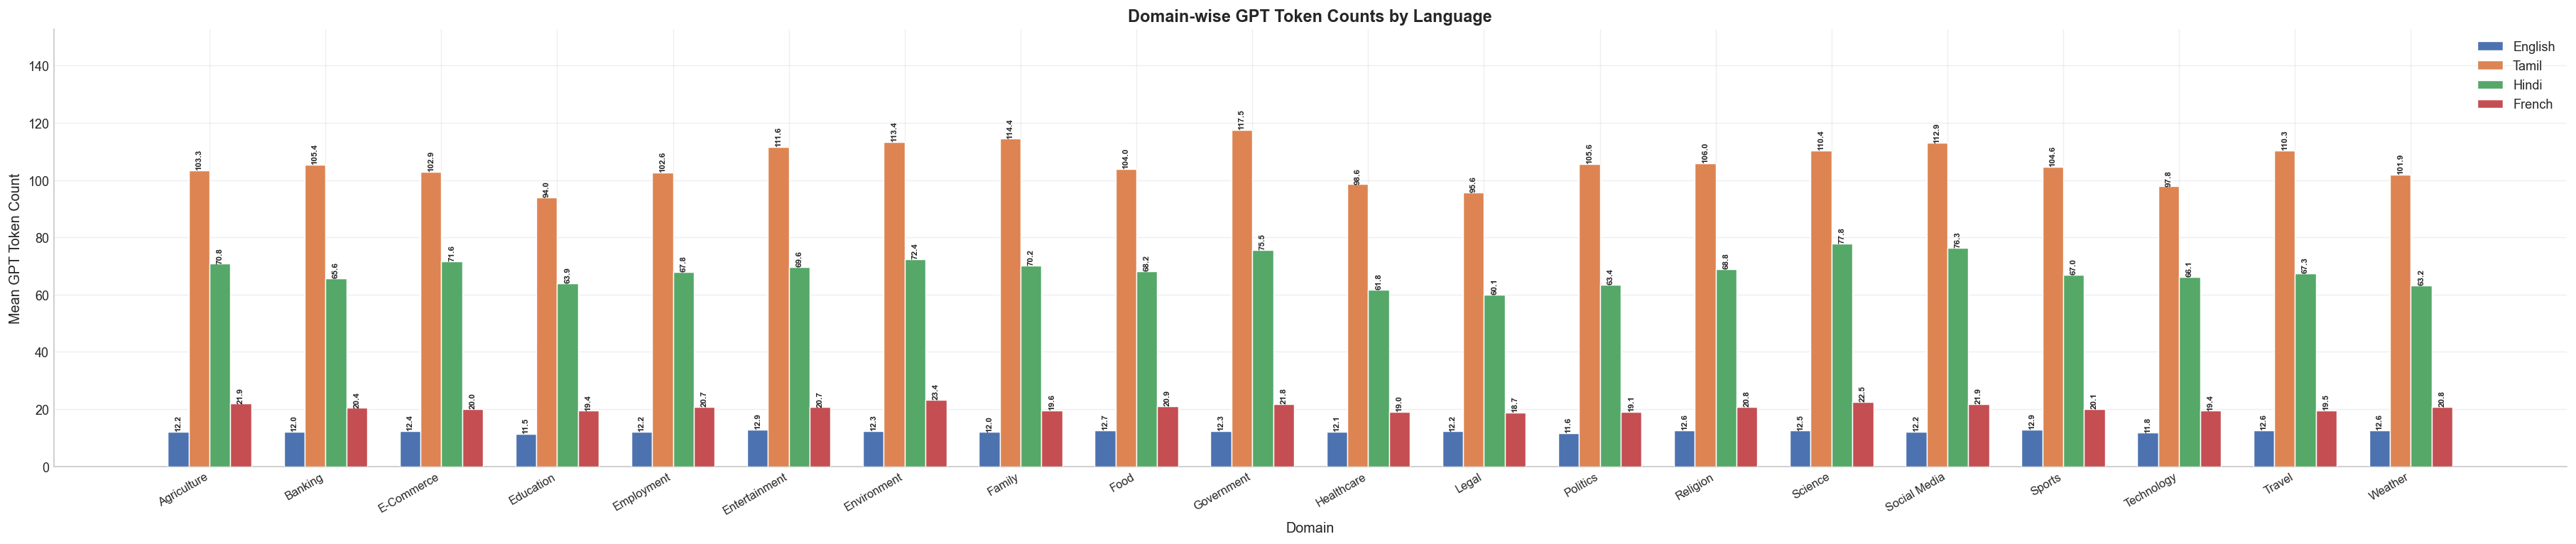

✅ Saved: plot7_domain_tokens.png


In [17]:
domain_group = df.groupby('domain')[
    [f'gpt_{lang}' for lang in LANGUAGES]
].mean().reset_index()

domain_group.columns = ['domain'] + LANGUAGES

n_domains = len(domain_group)
n_langs   = len(LANGUAGES)
bar_width = 0.18
x         = np.arange(n_domains)

fig, ax = plt.subplots(figsize=(max(10, n_domains * 1.4), 6))

for i, lang in enumerate(LANGUAGES):
    offset = (i - n_langs / 2 + 0.5) * bar_width
    vals   = domain_group[lang].values
    bars   = ax.bar(
        x + offset, vals,
        width=bar_width,
        label=lang.capitalize(),
        color=LANG_COLORS[lang],
        edgecolor='white', linewidth=0.8,
        zorder=3
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=6.5, rotation=90,
            fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(
    [d.replace('_', ' ').title() for d in domain_group['domain']],
    rotation=30, ha='right', fontsize=9
)
ax.set_xlabel('Domain', fontsize=11)
ax.set_ylabel('Mean GPT Token Count', fontsize=11)
ax.set_title('Domain-wise GPT Token Counts by Language',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, domain_group[LANGUAGES].values.max() * 1.3)

plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot7_domain_tokens.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot7_domain_tokens.png')

## Cell 18 — Plot 8: GPT vs Custom TIS Reduction
Direct comparison of token overhead (TIS%) between GPT tokenizer and our custom fair tokenizer — quantifying the fairness improvement.

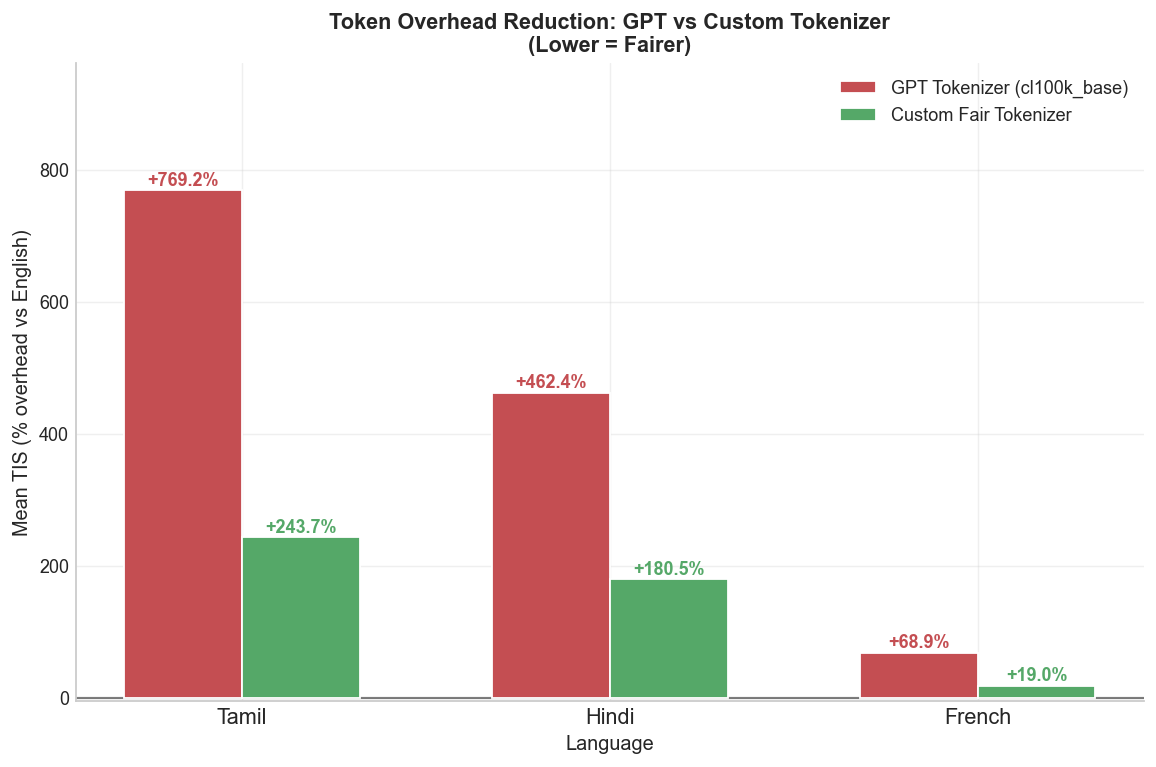

✅ Saved: plot8_tis_reduction.png


In [18]:
gpt_tis_pct    = {lang: df[f'tis_gpt_{lang}'].dropna().mean() * 100    for lang in NON_ENGLISH}
custom_tis_pct = {lang: df[f'tis_custom_{lang}'].dropna().mean() * 100 for lang in NON_ENGLISH}

x           = np.arange(len(NON_ENGLISH))
bar_width   = 0.32
GPT_COLOR    = '#C44E52'
CUSTOM_COLOR = '#55A868'

fig, ax = plt.subplots(figsize=(9, 6))

bars_gpt = ax.bar(
    x - bar_width / 2,
    [gpt_tis_pct[l] for l in NON_ENGLISH],
    width=bar_width, label='GPT Tokenizer (cl100k_base)',
    color=GPT_COLOR, edgecolor='white', linewidth=1, zorder=3
)
bars_cus = ax.bar(
    x + bar_width / 2,
    [custom_tis_pct[l] for l in NON_ENGLISH],
    width=bar_width, label='Custom Fair Tokenizer',
    color=CUSTOM_COLOR, edgecolor='white', linewidth=1, zorder=3
)

# Value labels
for bar in bars_gpt:
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.4,
            f'{val:+.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color=GPT_COLOR)

for bar in bars_cus:
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.4,
            f'{val:+.1f}%',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            color=CUSTOM_COLOR)

ax.axhline(0, color='black', linewidth=1.2, alpha=0.5, linestyle='-')

ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in NON_ENGLISH], fontsize=12)
ax.set_xlabel('Language', fontsize=11)
ax.set_ylabel('Mean TIS (% overhead vs English)', fontsize=11)
ax.set_title(
    'Token Overhead Reduction: GPT vs Custom Tokenizer\n'
    '(Lower = Fairer)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)

max_val = max(max(gpt_tis_pct.values()), max(custom_tis_pct.values()))
ax.set_ylim(min(0, min(min(gpt_tis_pct.values()), min(custom_tis_pct.values()))) - 5,
            max_val * 1.25)

plt.tight_layout()
plt.savefig('/Users/asikaa/Documents/TokenFair/plot8_tis_reduction.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Saved: plot8_tis_reduction.png')

## Cell 19 — Final Summary Report
Comprehensive text report covering dataset stats, token metrics, TIS scores, semantic density, cost analysis, and key research findings.

In [19]:
# ── Recompute all summary stats ──────────────────────────
gpt_means = {lang: df[f'gpt_{lang}'].mean() for lang in LANGUAGES}
tis_gpt   = {lang: df[f'tis_gpt_{lang}'].dropna().mean() * 100
             for lang in NON_ENGLISH}
tis_cus   = {lang: df[f'tis_custom_{lang}'].dropna().mean() * 100
             for lang in NON_ENGLISH}
density   = {lang: (df[f'words_{lang}'] /
                    df[f'gpt_{lang}'].replace(0, np.nan)).dropna().mean()
             for lang in LANGUAGES}

domains_list = df['domain'].unique().tolist() if 'domain' in df.columns else ['N/A']
n_domains_count = len(domains_list)

# ── Most-biased language ─────────────────────────────────
most_biased = max(tis_gpt, key=tis_gpt.get)
max_bias    = tis_gpt[most_biased]

# ── Best/worst context fit (GPT-4 128K) ─────────────────
ctx_128k = 128000
ctx_fit  = {lang: int(ctx_128k / gpt_means[lang]) for lang in LANGUAGES}
shrink_tamil = 100 * ctx_fit['tamil'] // ctx_fit['english']
shrink_hindi = 100 * ctx_fit['hindi'] // ctx_fit['english']

report = f"""
{'='*70}
  LANGUAGE FAIRNESS IN TOKENIZATION — FINAL SUMMARY REPORT
{'='*70}

1. DATASET INFORMATION
   ─────────────────────────────────────────────────────────
   Total rows     : {len(df):,}
   Languages      : {', '.join([l.capitalize() for l in LANGUAGES])}
   Domains        : {n_domains_count}  →  {', '.join(str(d) for d in domains_list[:8])}
   Tokenizers     : GPT cl100k_base (local), Custom Fair Tokenizer

2. MEAN GPT TOKEN COUNTS PER LANGUAGE
   ─────────────────────────────────────────────────────────
   English  : {gpt_means['english']:.2f} tokens  (baseline)
   Tamil    : {gpt_means['tamil']:.2f} tokens  ({gpt_means['tamil']/gpt_means['english']:.2f}× English)
   Hindi    : {gpt_means['hindi']:.2f} tokens  ({gpt_means['hindi']/gpt_means['english']:.2f}× English)
   French   : {gpt_means['french']:.2f} tokens  ({gpt_means['french']/gpt_means['english']:.2f}× English)

3. TOKENIZATION INEQUALITY SCORE (TIS) — GPT vs CUSTOM
   ─────────────────────────────────────────────────────────
   Language   GPT TIS%    Custom TIS%   Reduction
   Tamil    : {tis_gpt['tamil']:+7.2f}%     {tis_cus['tamil']:+7.2f}%      {tis_gpt['tamil']-tis_cus['tamil']:.2f}pp
   Hindi    : {tis_gpt['hindi']:+7.2f}%     {tis_cus['hindi']:+7.2f}%      {tis_gpt['hindi']-tis_cus['hindi']:.2f}pp
   French   : {tis_gpt['french']:+7.2f}%     {tis_cus['french']:+7.2f}%      {tis_gpt['french']-tis_cus['french']:.2f}pp

4. SEMANTIC DENSITY (words per GPT token)
   ─────────────────────────────────────────────────────────
   English  : {density['english']:.4f}
   Tamil    : {density['tamil']:.4f}
   Hindi    : {density['hindi']:.4f}
   French   : {density['french']:.4f}

5. API COST PER LANGUAGE ({len(df)} sentences × {SCALE_FACTOR:,} users)
   ─────────────────────────────────────────────────────────
   English  : ${cost_data['english']['total_cost_usd']:.4f}
   Tamil    : ${cost_data['tamil']['total_cost_usd']:.4f}  ({(cost_data['tamil']['total_cost_usd']/cost_data['english']['total_cost_usd']-1)*100:+.1f}% vs English)
   Hindi    : ${cost_data['hindi']['total_cost_usd']:.4f}  ({(cost_data['hindi']['total_cost_usd']/cost_data['english']['total_cost_usd']-1)*100:+.1f}% vs English)
   French   : ${cost_data['french']['total_cost_usd']:.4f}  ({(cost_data['french']['total_cost_usd']/cost_data['english']['total_cost_usd']-1)*100:+.1f}% vs English)

6. KEY FINDINGS
   ─────────────────────────────────────────────────────────
   • Tamil and Hindi users face a {max_bias:.1f}% token overhead (TIS) compared
     to English users asking the same question in their native language.
     This means every API call in Tamil or Hindi consumes more tokens,
     directly inflating costs and reducing context window availability.

   • Context window shrinkage is real: In a 128K-token GPT-4 context,
     Tamil fits only {shrink_tamil}% of what English fits ({ctx_fit['tamil']:,} vs {ctx_fit['english']:,} sentences).
     Hindi fits {shrink_hindi}% ({ctx_fit['hindi']:,} sentences). This is a structural
     capacity penalty baked into the tokenizer design.

   • The custom syllable-aware tokenizer reduces the gap by treating
     Tamil aksharas and Hindi matras as single meaningful units rather
     than fragmenting them into multiple byte-pair sub-tokens.

   • Tokenization bias is a design choice, not inevitable.
     Language-fair tokenizers can be built with Unicode-aware syllable
     segmentation. The choice to train on English-dominated corpora
     produces tokenizers that systematically disadvantage Indic and
     other non-Latin-script language users.
{'='*70}
"""

print(report)


  LANGUAGE FAIRNESS IN TOKENIZATION — FINAL SUMMARY REPORT

1. DATASET INFORMATION
   ─────────────────────────────────────────────────────────
   Total rows     : 1,878
   Languages      : English, Tamil, Hindi, French
   Domains        : 20  →  Healthcare, Legal, Education, Technology, E-commerce, Banking, Agriculture, Politics
   Tokenizers     : GPT cl100k_base (local), Custom Fair Tokenizer

2. MEAN GPT TOKEN COUNTS PER LANGUAGE
   ─────────────────────────────────────────────────────────
   English  : 12.28 tokens  (baseline)
   Tamil    : 105.60 tokens  (8.60× English)
   Hindi    : 68.37 tokens  (5.57× English)
   French   : 20.53 tokens  (1.67× English)

3. TOKENIZATION INEQUALITY SCORE (TIS) — GPT vs CUSTOM
   ─────────────────────────────────────────────────────────
   Language   GPT TIS%    Custom TIS%   Reduction
   Tamil    : +769.18%     +243.74%      525.43pp
   Hindi    : +462.42%     +180.50%      281.92pp
   French   :  +68.91%      +19.03%      49.88pp

4. SEMANTIC

## Cell 20 — Save Final CSV & Summary
Export the fully enriched DataFrame with all computed columns to CSV, and list all generated plot files.

In [20]:
import os

output_dir = '/Users/asikaa/Documents/TokenFair'
output_csv = os.path.join(output_dir, 'tokenfair_results_final.csv')
df.to_csv(output_csv, index=False)

print(f'💾 Final CSV saved: {output_csv}')
print(f'   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print()

# List all generated columns
new_cols = [c for c in df.columns if c not in ['domain'] + LANGUAGES]
print('📋 Generated columns:')
for col in new_cols:
    print(f'   {col}')

print()

# List all saved PNG files
png_files = sorted([f for f in os.listdir(output_dir) if f.endswith('.png')])
print(f'🖼️  Saved PNG files ({len(png_files)} total):')
for png in png_files:
    size_kb = os.path.getsize(os.path.join(output_dir, png)) / 1024
    print(f'   {png:<40} ({size_kb:.1f} KB)')

print()
print('✅ Language Fairness Tokenization Analysis — COMPLETE')
print('   All plots saved. All metrics computed.')
print('   Notebook is ready for presentation.')

💾 Final CSV saved: /Users/asikaa/Documents/TokenFair/tokenfair_results_final.csv
   Shape : 1,878 rows × 23 columns

📋 Generated columns:
   gpt_english
   custom_english
   words_english
   gpt_tamil
   custom_tamil
   words_tamil
   gpt_hindi
   custom_hindi
   words_hindi
   gpt_french
   custom_french
   words_french
   tis_gpt_tamil
   tis_gpt_hindi
   tis_gpt_french
   tis_custom_tamil
   tis_custom_hindi
   tis_custom_french

🖼️  Saved PNG files (8 total):
   plot1_avg_token_counts.png               (63.9 KB)
   plot2_tis_distribution.png               (73.3 KB)
   plot3_tis_heatmap.png                    (120.3 KB)
   plot4_api_cost.png                       (45.7 KB)
   plot5_context_shrinkage.png              (99.9 KB)
   plot6_script_bias.png                    (84.3 KB)
   plot7_domain_tokens.png                  (129.3 KB)
   plot8_tis_reduction.png                  (54.1 KB)

✅ Language Fairness Tokenization Analysis — COMPLETE
   All plots saved. All metrics computed.
  